# Polycrystalline gold digital twin

This notebook demonstrates a voxel-based polycrystalline Au-rich slab and its matching digital-twin aberration corrector. The sample generator creates a labeled 3D volume of blobby regions. Occupied regions carry Euler orientation and composition parameters; selected regions are explicitly empty. The 3D orientation-dependent potential is projected along the beam and convolved with a probe calculated by `pyTEMlib.probe_tools.get_probe` from the corrector coefficients.

The corrector is a separate Tango device, matching the real CEOS corrector's command inputs and JSON response structure. Changing microscope defocus updates the twin corrector's `C1` coefficient, and the next HAADF acquisition uses the resulting probe.


## Start the digital twin

From the repository root, install the diffraction dependencies if needed and start the stack in a terminal:

```bash
uv sync --extra diffraction
uv run python startup_scripts/run_servers.py --yaml configs/polycrystalline_gold.yaml
```

Leave that terminal open while using the notebook. The standard config exposes Tango on `127.0.0.1:9094` and Tiled on `http://127.0.0.1:9091`. For isolated validation, the environment variables `ASYNCROSCOPY_TANGO_HOST` and `ASYNCROSCOPY_TILED_URL` can override those client endpoints without changing the YAML.


In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tango
from IPython.display import Markdown, display
from tiled.client import from_uri

%matplotlib ipympl

TANGO_HOST = os.getenv("ASYNCROSCOPY_TANGO_HOST", "127.0.0.1:9094")
TILED_URL = os.getenv("ASYNCROSCOPY_TILED_URL", "http://127.0.0.1:9091")
os.environ["TANGO_HOST"] = TANGO_HOST
print("Tango:", TANGO_HOST)
print("Tiled:", TILED_URL)


Tango: 127.0.0.1:9094
Tiled: http://127.0.0.1:9091


In [2]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
corrector = tango.DeviceProxy("asyncroscopy/corrector/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in (scan, microscope, corrector, data):
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

client = from_uri(TILED_URL)


asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/corrector/default ON
asyncroscopy/data/default ON


## Inspect the generated 3D slab

The configured slab spans **200 nm × 200 nm × 20 nm**. The metadata reports the actual voxel volume and occupied/empty region counts. Region parameters are designed to be extended with additional physical fields later; the current implementation stores orientation and Au/Ag composition for occupied blobs and no parameters for empty blobs.


,value
sample_type,polycrystalline_gold_slab
volume_shape_zyx,"[40, 400, 400]"
voxel_size_nm,0.5
volume_size_xy_nm,200.0
volume_thickness_nm,20.0
region_count,18
occupied_region_count,14
empty_region_count,4
defocus_m,0.0
corrector_aberrations,"{'WD': [0.0, 0.0], 'C1': [0.0], 'A1': [0.0, 3...."


,label,occupied,orientation_euler_deg,composition,voxel_count
0,1,False,None,{},747047
1,2,True,"[38.73709363928007, 10.298011375380355, 131.98...","{'Au': 0.928140694428237, 'Ag': 0.071859305571...",224460
2,3,True,"[279.27226045755873, 45.77062522107756, 63.596...","{'Au': 0.9385918650181289, 'Ag': 0.06140813498...",173222
3,4,True,"[164.14902345439918, 240.66468686389885, 37.18...","{'Au': 0.9960131444024365, 'Ag': 0.00398685559...",539680
4,5,True,"[90.05047721363893, 113.05601976739281, 153.91...","{'Au': 0.9179471962982586, 'Ag': 0.08205280370...",47130
5,6,True,"[190.2953571470067, 72.60286808684765, 317.863...","{'Au': 0.9336276457306266, 'Ag': 0.06637235426...",611335
6,7,True,"[54.7288096553806, 238.13718884113962, 213.978...","{'Au': 0.961196821390414, 'Ag': 0.038803178609...",331355
7,8,True,"[170.89938869129952, 55.81901282281574, 306.73...","{'Au': 0.9193420336716305, 'Ag': 0.08065796632...",208466
8,9,True,"[226.58891059835932, 90.24110397562593, 34.565...","{'Au': 0.9571520797878778, 'Ag': 0.04284792021...",492297
9,10,False,None,{},214491


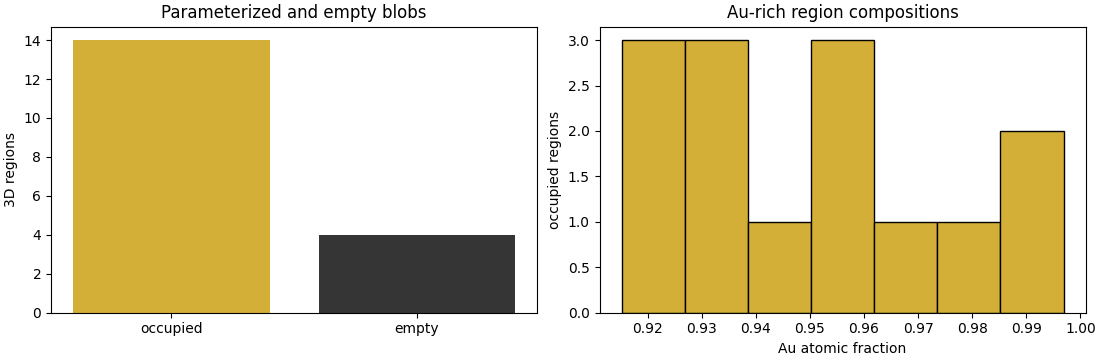

In [3]:
volume_metadata = json.loads(microscope.get_volume_metadata())
region_parameters = pd.DataFrame(json.loads(microscope.get_region_parameters()))

display(pd.Series(volume_metadata, name="value").to_frame())
display(region_parameters)

occupied_regions = region_parameters[region_parameters["occupied"]].copy()
empty_regions = region_parameters[~region_parameters["occupied"]].copy()
occupied_regions["gold_fraction"] = occupied_regions["composition"].map(lambda value: value["Au"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].bar(
    ["occupied", "empty"],
    [len(occupied_regions), len(empty_regions)],
    color=["#d4af37", "#353535"],
)
axes[0].set_ylabel("3D regions")
axes[0].set_title("Parameterized and empty blobs")
axes[1].hist(occupied_regions["gold_fraction"], bins=7, color="#d4af37", edgecolor="black")
axes[1].set_xlabel("Au atomic fraction")
axes[1].set_ylabel("occupied regions")
axes[1].set_title("Au-rich region compositions")
plt.show()


## Acquire a corrector-driven defocus series

A `20 nm` field of view resolves the orientation-dependent projected potential. The scan settings remain fixed while defocus is varied symmetrically around zero. Each command saves a new acquisition; Tiled supplies the full numerical array and its probe/corrector metadata.


In [4]:
scan.imsize = 256
scan.dwell_time = 1e-6
scan.scan_region = [0.0, 0.0, 1.0, 1.0]
microscope.set_fov(20e-9)

defocus_nm = np.array([-30.0, -15.0, 0.0, 15.0, 30.0])
images = []
acquisition_rows = []

for value_nm in defocus_nm:
    microscope.set_defocus(float(value_nm * 1e-9))
    key = microscope.acquire_scanned_image(["HAADF"])
    node = client[key]["image"]["HAADF"]
    image = np.asarray(node.read(), dtype=np.float64)
    metadata = dict(node.metadata)
    images.append(image)

    centered = image - image.mean()
    power = np.abs(np.fft.rfft2(centered)) ** 2
    fy = np.fft.fftfreq(image.shape[0])[:, None]
    fx = np.fft.rfftfreq(image.shape[1])[None, :]
    high_frequency = np.hypot(fx, fy) >= 0.20
    acquisition_rows.append({
        "defocus_nm": value_nm,
        "key": key,
        "metadata_defocus_nm": float(metadata["defocus_m"]) * 1e9,
        "mean": float(image.mean()),
        "standard_deviation": float(image.std()),
        "high_frequency_power": float(power[high_frequency].sum() / power.sum()),
        "probe_backend": metadata["probe_backend"],
    })

images = np.asarray(images)
defocus_results = pd.DataFrame(acquisition_rows)
display(defocus_results)


,defocus_nm,key,metadata_defocus_nm,mean,standard_deviation,high_frequency_power,probe_backend
0,-30.0,stem_image_HAADF_20260811T160317556989.h5,-29.999999,0.541078,0.219319,0.005808,pyTEMlib.probe_tools.get_probe
1,-15.0,stem_image_HAADF_20260811T160319232633.h5,-14.999999,0.505644,0.208620,0.005507,pyTEMlib.probe_tools.get_probe
2,0.0,stem_image_HAADF_20260811T160319335635.h5,0.000000,0.481302,0.190693,0.005835,pyTEMlib.probe_tools.get_probe
3,15.0,stem_image_HAADF_20260811T160319438050.h5,14.999999,0.505833,0.208864,0.005504,pyTEMlib.probe_tools.get_probe
4,30.0,stem_image_HAADF_20260811T160319537942.h5,29.999999,0.541063,0.219491,0.005802,pyTEMlib.probe_tools.get_probe


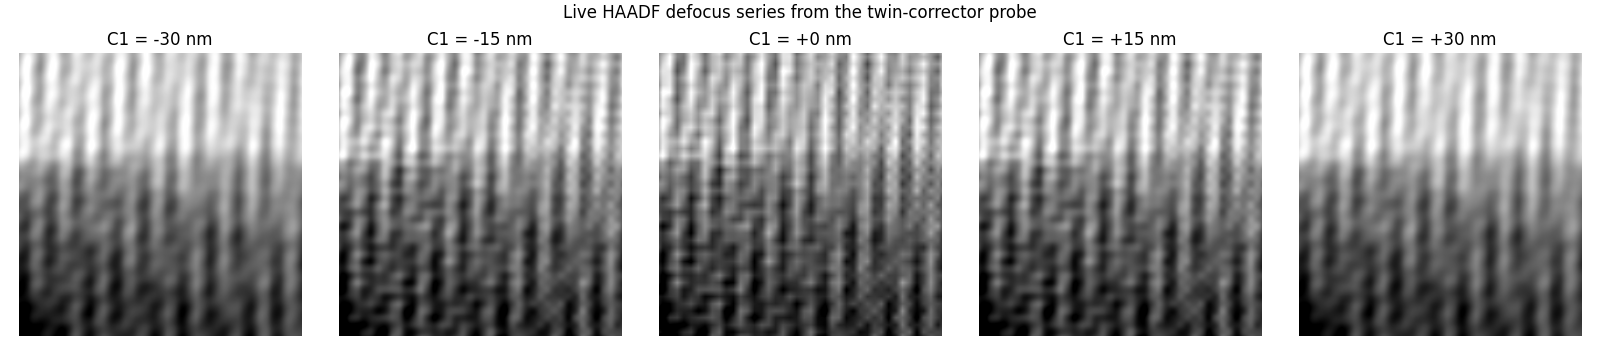

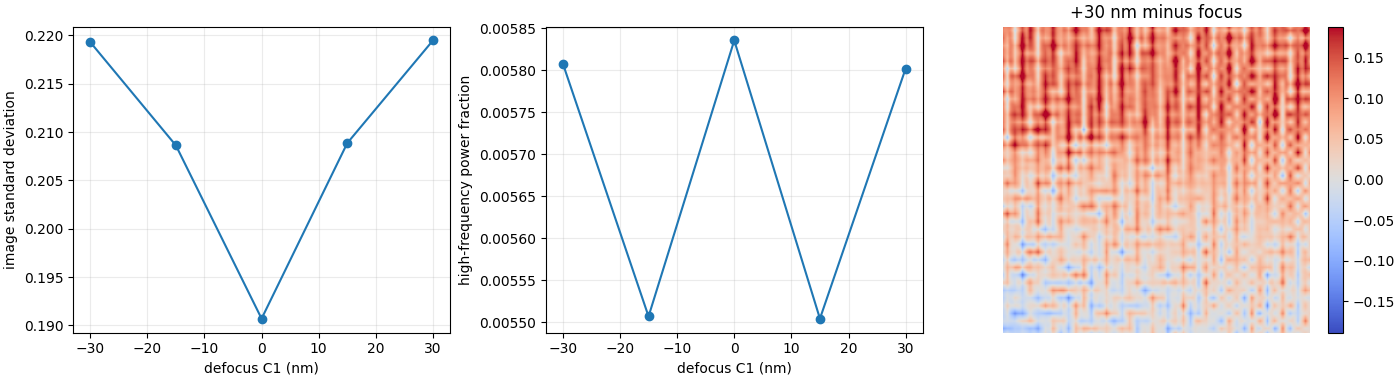

In [5]:
fig, axes = plt.subplots(1, len(defocus_nm), figsize=(16, 3.4), constrained_layout=True)
vmin, vmax = np.percentile(images, [1, 99])
for axis, value_nm, image in zip(axes, defocus_nm, images):
    axis.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
    axis.set_title(f"C1 = {value_nm:+.0f} nm")
    axis.axis("off")
fig.suptitle("Live HAADF defocus series from the twin-corrector probe")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
axes[0].plot(defocus_results["defocus_nm"], defocus_results["standard_deviation"], "o-")
axes[0].set_ylabel("image standard deviation")
axes[1].plot(defocus_results["defocus_nm"], defocus_results["high_frequency_power"], "o-")
axes[1].set_ylabel("high-frequency power fraction")
difference = images[-1] - images[2]
limit = np.percentile(np.abs(difference), 99)
im = axes[2].imshow(difference, cmap="coolwarm", vmin=-limit, vmax=limit)
axes[2].set_title("+30 nm minus focus")
axes[2].axis("off")
fig.colorbar(im, ax=axes[2], fraction=0.046)
for axis in axes[:2]:
    axis.set_xlabel("defocus C1 (nm)")
    axis.grid(alpha=0.25)
plt.show()


In [6]:
zero_index = int(np.where(defocus_nm == 0.0)[0][0])
edge_index = int(np.where(defocus_nm == 30.0)[0][0])
mean_absolute_change = float(np.mean(np.abs(images[edge_index] - images[zero_index])))
contrast_change_percent = float(
    100.0
    * (
        defocus_results.loc[edge_index, "standard_deviation"]
        / defocus_results.loc[zero_index, "standard_deviation"]
        - 1.0
    )
)

display(Markdown(
    f'''## Conclusions

- The generated sample is a **{volume_metadata['volume_shape_zyx'][0]} × {volume_metadata['volume_shape_zyx'][1]} × {volume_metadata['volume_shape_zyx'][2]} voxel** slab with **{volume_metadata['occupied_region_count']} occupied** orientation/composition regions and **{volume_metadata['empty_region_count']} empty** regions. The measured occupied voxel fraction is **{volume_metadata['occupied_voxel_fraction']:.1%}**.
- Every saved image reports `probe_backend = pyTEMlib.probe_tools.get_probe`, and the Tiled metadata defocus matches each requested `C1` value.
- Moving from focus to **+30 nm** defocus changed the image by a mean absolute intensity of **{mean_absolute_change:.4f}** and changed image standard deviation by **{contrast_change_percent:+.1f}%** with all scan and noise settings held fixed.
- The ±defocus images are expected to be nearly symmetric for the present coefficient set. Additional astigmatism or higher-order coefficients can be applied through the same corrector API to break that symmetry and extend the experiment.
'''
))


## Conclusions

- The generated sample is a **40 × 400 × 400 voxel** slab with **14 occupied** orientation/composition regions and **4 empty** regions. The measured occupied voxel fraction is **68.5%**.
- Every saved image reports `probe_backend = pyTEMlib.probe_tools.get_probe`, and the Tiled metadata defocus matches each requested `C1` value.
- Moving from focus to **+30 nm** defocus changed the image by a mean absolute intensity of **0.0653** and changed image standard deviation by **+15.1%** with all scan and noise settings held fixed.
- The ±defocus images are expected to be nearly symmetric for the present coefficient set. Additional astigmatism or higher-order coefficients can be applied through the same corrector API to break that symmetry and extend the experiment.
